In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
# Make sure the CSV file is in the same folder as your notebook
df = pd.read_csv('sales_data_with_discounts.csv')

# Display first few rows and data info
print("First 5 rows of the dataset:")
display(df.head())

print("\nData Info:")
print(df.info())

First 5 rows of the dataset:


,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB
None


In [ ]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Calculate statistics
stats_dict = {}
for col in numerical_cols:
    stats_dict[col] = {
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Mode': df[col].mode()[0],
        'Standard Deviation': df[col].std()
    }

# Display statistics as a dataframe
stats_df = pd.DataFrame(stats_dict).T
print("\nDescriptive Statistics:")
display(stats_df)


Descriptive Statistics:


,Mean,Median,Mode,Standard Deviation
Volume,5.066667,4.000000,3.000000,4.231602
Avg Price,10453.433333,1450.000000,400.000000,18079.904840
Total Sales Value,33812.835556,5700.000000,24300.000000,50535.074173
Discount Rate (%),15.155242,16.577766,5.007822,4.220602
Discount Amount,3346.499424,988.933733,69.177942,4509.902963
Net Sales Value,30466.336131,4677.788059,326.974801,46358.656624


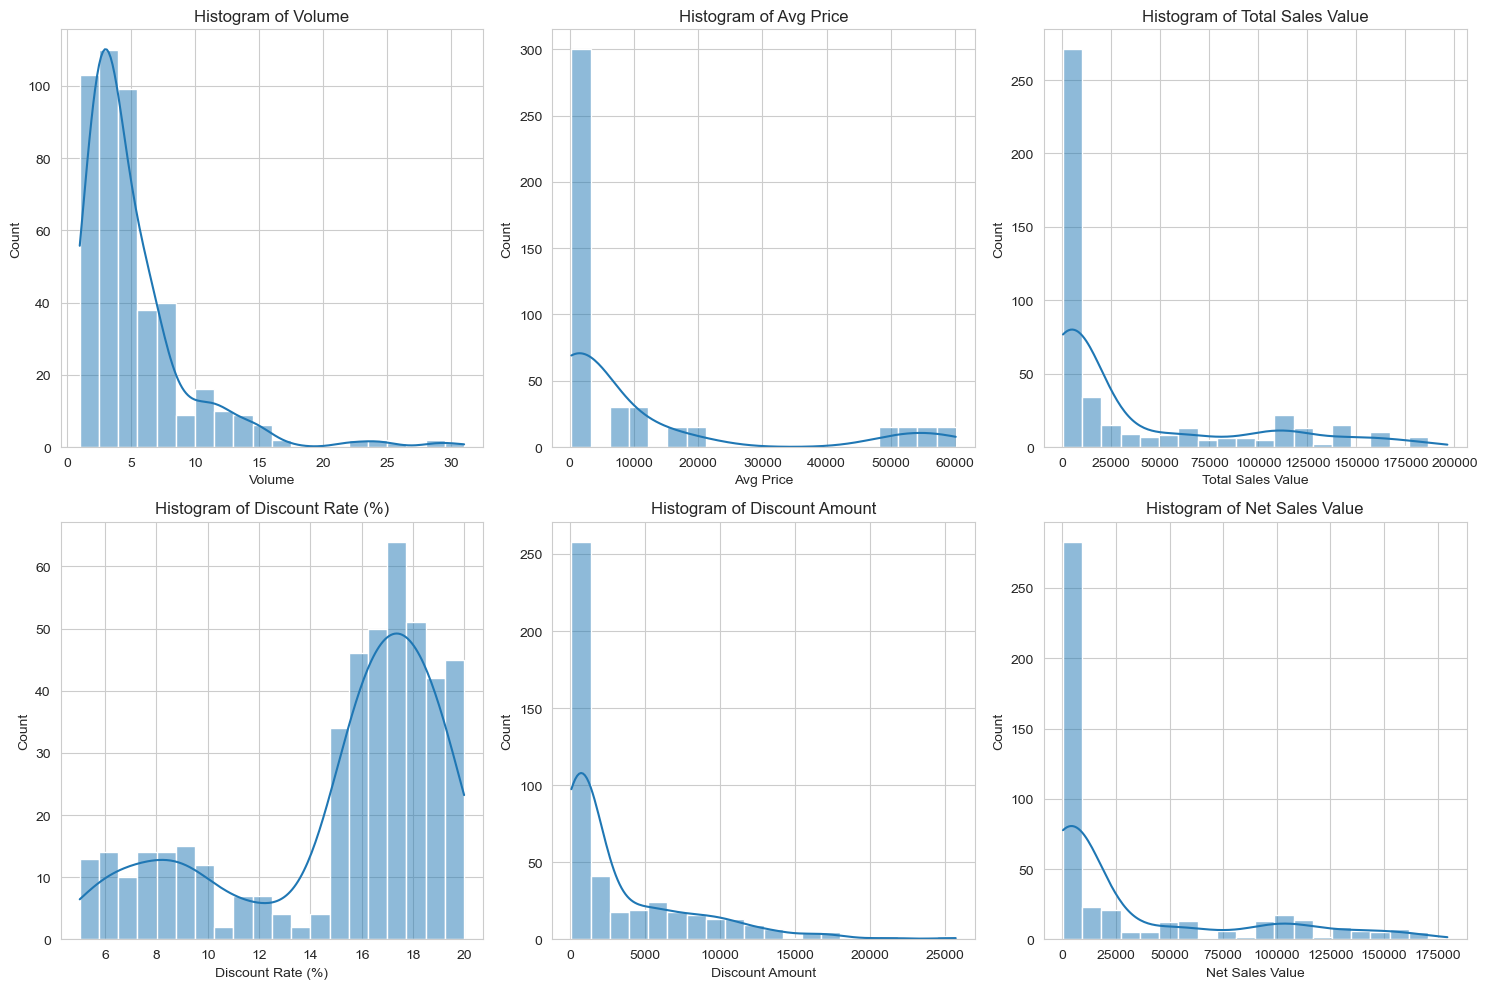

In [ ]:
# Set plot style
sns.set_style("whitegrid")

# Plot Histograms
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()


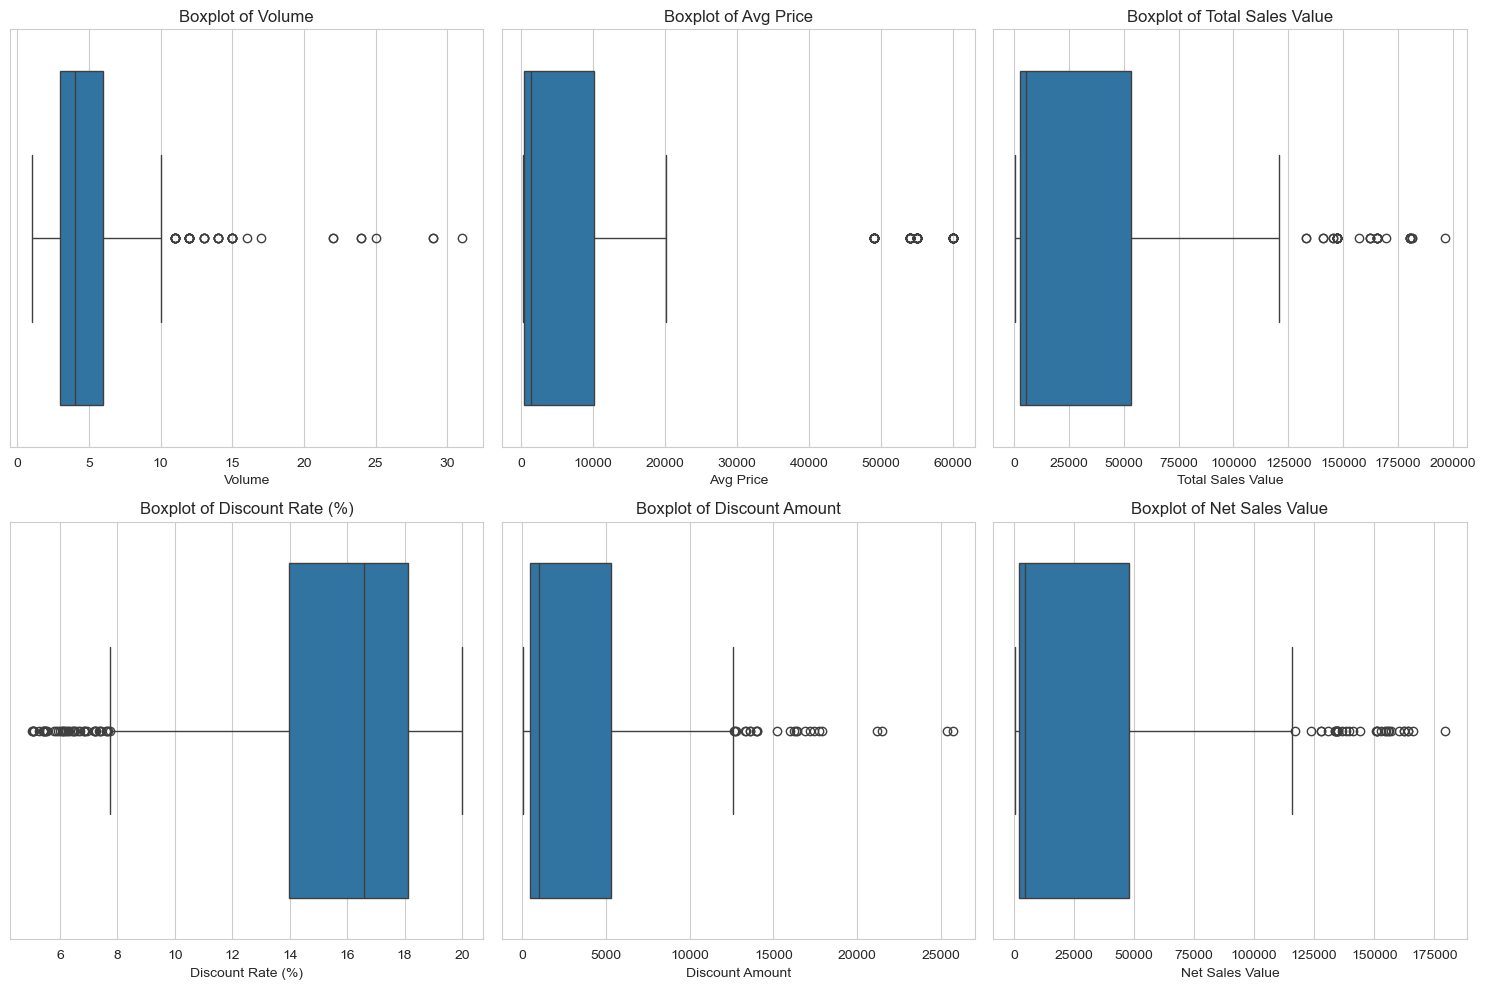

In [ ]:
# Plot Boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

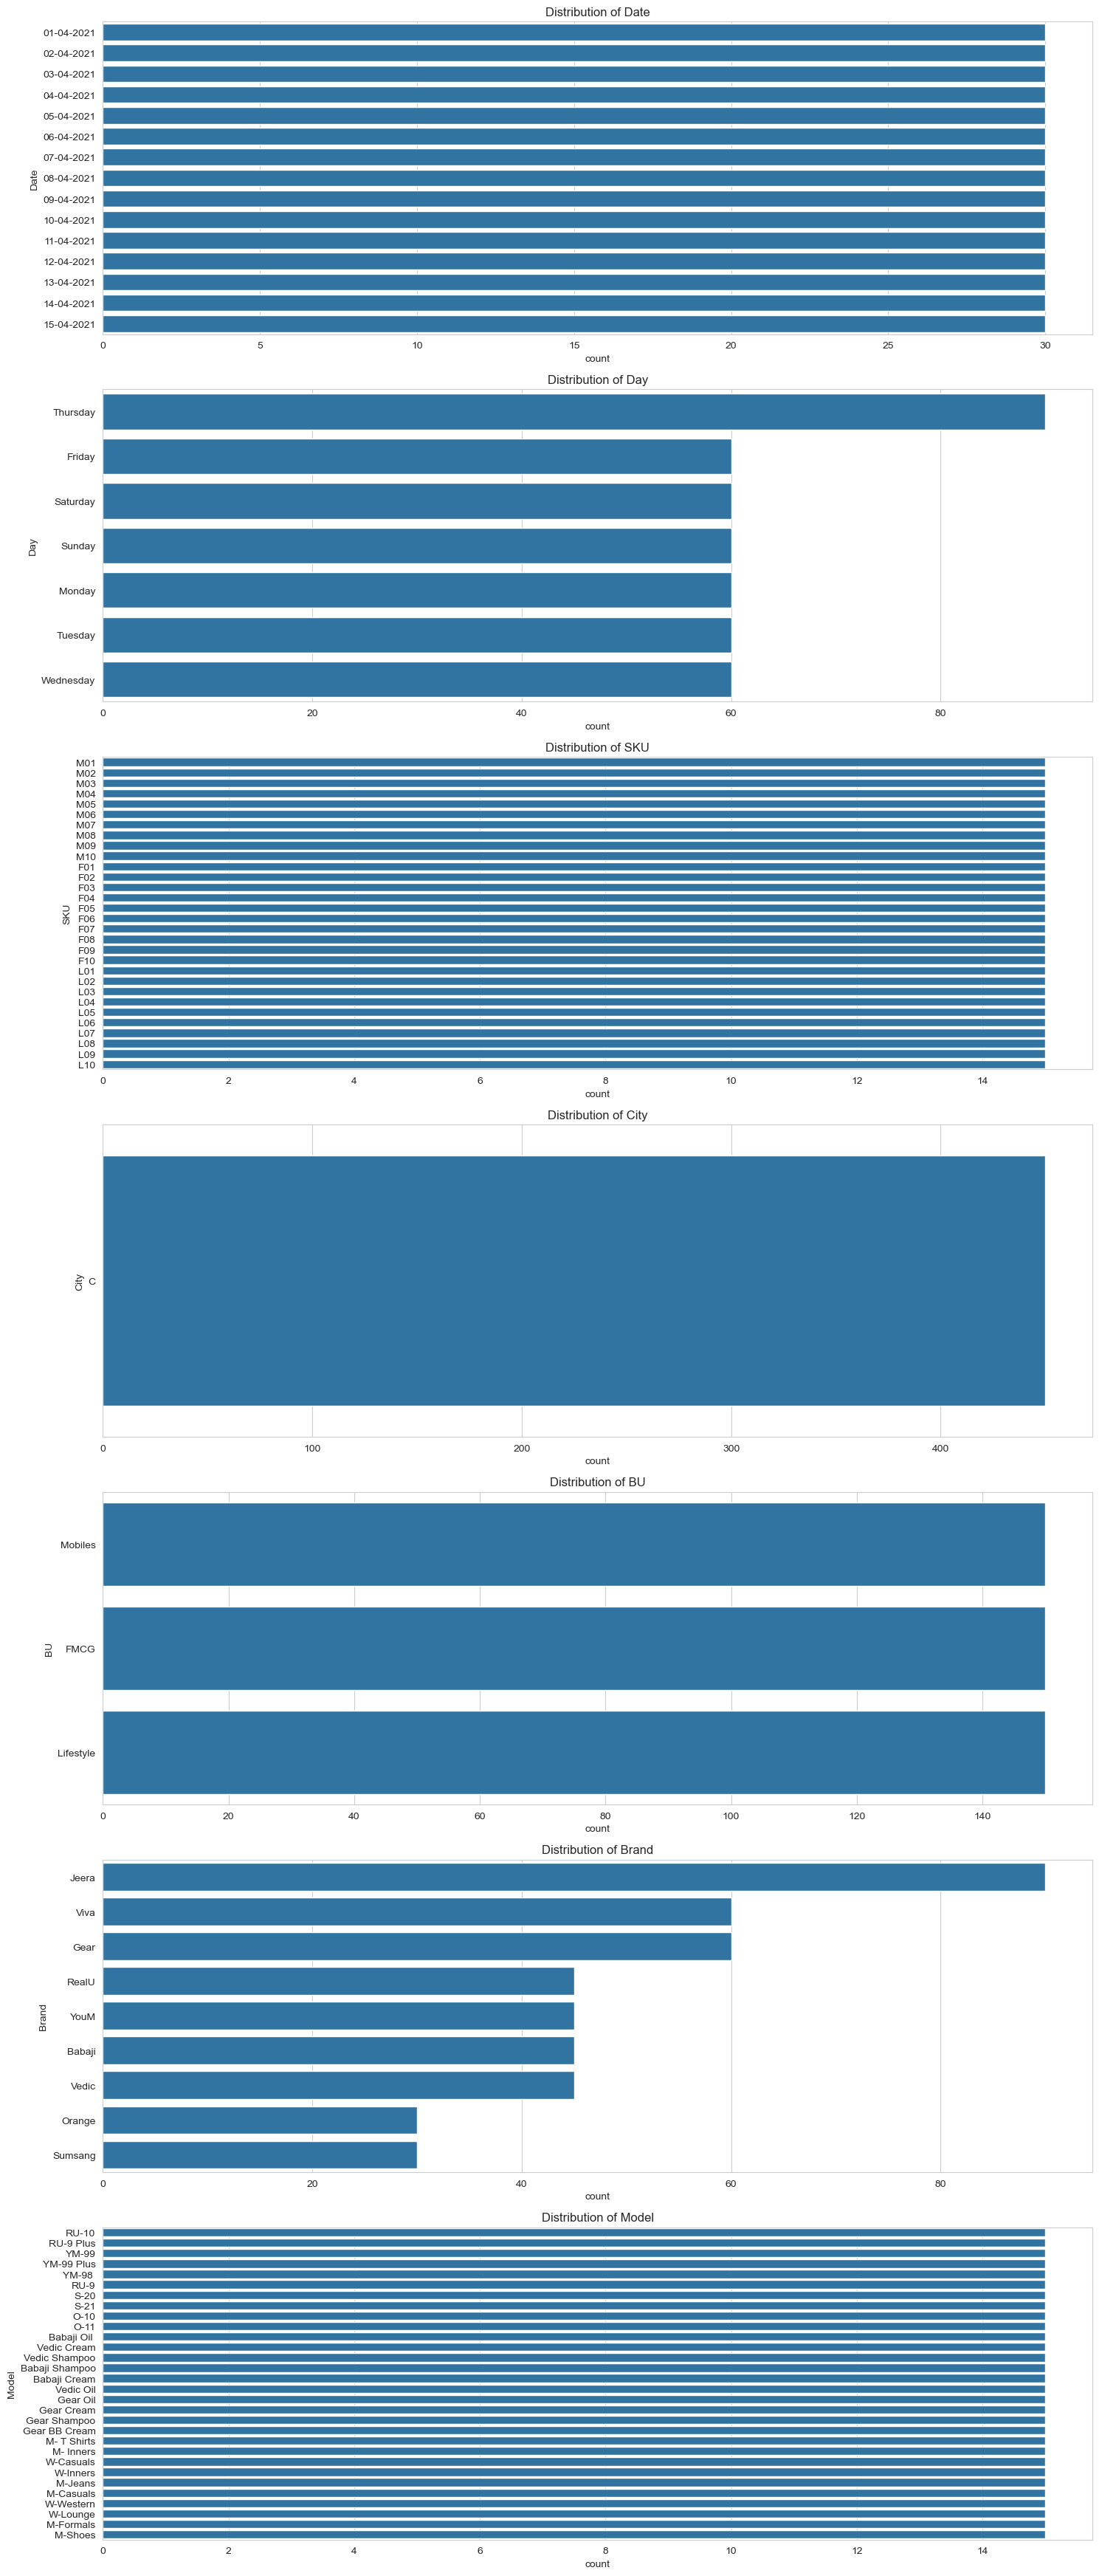

In [ ]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Filter out 'Date' as it has too many unique values for a simple bar chart
cat_cols_for_plot = [col for col in categorical_cols if df[col].nunique() < 50]

# Plot Bar Charts
plt.figure(figsize=(15, 5 * len(cat_cols_for_plot)))
for i, col in enumerate(cat_cols_for_plot):
    plt.subplot(len(cat_cols_for_plot), 1, i + 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [ ]:
# Create a copy of the dataframe for standardization
df_standardized = df.copy()

# Apply Standardization: z = (x - mu) / sigma
for col in numerical_cols:
    mu = df[col].mean()
    sigma = df[col].std()
    df_standardized[col] = (df[col] - mu) / sigma

print("Standardized Data (First 5 Rows):")
display(df_standardized[numerical_cols].head())

Standardized Data (First 5 Rows):


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,2.347417,0.091072,2.922469,-0.829365,3.948422,2.801638
1,1.165831,-0.019548,1.329516,-0.851714,1.846958,1.269613
2,0.456880,0.312312,1.561038,-1.350129,1.621190,1.543957
3,0.220563,0.533552,1.717365,-1.947555,1.112568,1.763847
4,-0.488389,-0.130168,-0.188242,0.672990,0.227598,-0.227342


In [ ]:
# Define columns to encode (excluding 'Date' to keep the dataframe manageable)
cols_to_encode = [col for col in categorical_cols if col != 'Date']

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=cols_to_encode)

print("One-Hot Encoded Data (First 5 Rows):")
display(df_encoded.head())

print("\nList of new columns created:")
print(df_encoded.columns.tolist())

One-Hot Encoded Data (First 5 Rows):


,Date,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,Day_Friday,Day_Monday,Day_Saturday,...,Model_Vedic Cream,Model_Vedic Oil,Model_Vedic Shampoo,Model_W-Casuals,Model_W-Inners,Model_W-Lounge,Model_W-Western,Model_YM-98,Model_YM-99,Model_YM-99 Plus
0,01-04-2021,15,12100,181500,11.654820,21153.498820,160346.501180,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,01-04-2021,10,10100,101000,11.560498,11676.102961,89323.897039,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,01-04-2021,7,16100,112700,9.456886,10657.910157,102042.089843,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,01-04-2021,6,20100,120600,6.935385,8364.074702,112235.925298,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,01-04-2021,3,8100,24300,17.995663,4372.946230,19927.053770,False,False,False,...,False,False,False,False,False,False,False,True,False,False



List of new columns created:
['Date', 'Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value', 'Day_Friday', 'Day_Monday', 'Day_Saturday', 'Day_Sunday', 'Day_Thursday', 'Day_Tuesday', 'Day_Wednesday', 'SKU_F01', 'SKU_F02', 'SKU_F03', 'SKU_F04', 'SKU_F05', 'SKU_F06', 'SKU_F07', 'SKU_F08', 'SKU_F09', 'SKU_F10', 'SKU_L01', 'SKU_L02', 'SKU_L03', 'SKU_L04', 'SKU_L05', 'SKU_L06', 'SKU_L07', 'SKU_L08', 'SKU_L09', 'SKU_L10', 'SKU_M01', 'SKU_M02', 'SKU_M03', 'SKU_M04', 'SKU_M05', 'SKU_M06', 'SKU_M07', 'SKU_M08', 'SKU_M09', 'SKU_M10', 'City_C', 'BU_FMCG', 'BU_Lifestyle', 'BU_Mobiles', 'Brand_Babaji', 'Brand_Gear', 'Brand_Jeera', 'Brand_Orange', 'Brand_RealU', 'Brand_Sumsang', 'Brand_Vedic', 'Brand_Viva', 'Brand_YouM', 'Model_Babaji Cream', 'Model_Babaji Oil ', 'Model_Babaji Shampoo', 'Model_Gear BB Cream', 'Model_Gear Cream', 'Model_Gear Oil', 'Model_Gear Shampoo', 'Model_M- Inners', 'Model_M- T Shirts', 'Model_M-Casuals', 'Model_M-Formals', 'Model_